# Trabajo Práctico AA1 - Clasificación

In [2]:
# manipulación, visualización y modelado.
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# separación de datos, modelos y métricas.
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LogisticRegression
from sklearn.dummy import DummyClassifier

from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
from sklearn.metrics import classification_report
from sklearn.metrics import roc_curve, roc_auc_score, auc

# preprocesamiento.
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

## Carga dataset

In [7]:
# Cargamos el dataset
#df_original = pd.read_csv("/content/weatherAUS_2026C1.csv")
df_original = pd.read_csv("./content/weatherAUS_2026C1.csv")
df_original.head()

,Unnamed: 0,Date,Location,MinTemp,MaxTemp,Rainfall,Evaporation,Sunshine,WindGustDir,WindGustSpeed,...,Humidity3pm,Pressure9am,Pressure3pm,Cloud9am,Cloud3pm,Temp9am,Temp3pm,RainToday,RainTomorrow,RainfallTomorrow
0,0,2008-12-01,Albury,13.6,22.5,0.6,NaN,NaN,W,45.0,...,23.8,1008.1,1007.2,8.0,NaN,16.8,20.8,No,No,0.0
1,1,2008-12-02,Albury,7.3,25.8,0.0,NaN,NaN,WNW,44.0,...,22.1,1011.1,1007.5,NaN,NaN,18.3,24.6,No,No,0.0
2,2,2008-12-03,Albury,13.2,26.2,0.0,NaN,NaN,WSW,46.0,...,31.5,1007.3,1009.4,NaN,2.0,21.2,23.4,No,No,0.0
3,3,2008-12-04,Albury,10.0,28.8,0.0,NaN,NaN,NE,23.0,...,18.5,1017.6,1012.4,NaN,NaN,17.4,26.3,No,No,1.0
4,4,2008-12-05,Albury,17.4,32.4,1.0,NaN,NaN,W,41.0,...,34.6,1010.9,1005.9,7.0,8.0,17.9,29.1,No,No,0.2


In [8]:
#copiamos el dataset para mantener el original
df = df_original.copy()

In [10]:
# revisamos las columnas
df.columns

Index(['Unnamed: 0', 'Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall',
       'Evaporation', 'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am',
       'WindDir3pm', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm', 'RainToday', 'RainTomorrow', 'RainfallTomorrow'],
      dtype='str')

In [11]:
# cantidad de filas y columnas
df.shape

(145412, 25)

In [12]:
# revisamos tipos de datos y valores no nulos
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 145412 entries, 0 to 145411
Data columns (total 25 columns):
 #   Column            Non-Null Count   Dtype  
---  ------            --------------   -----  
 0   Unnamed: 0        145412 non-null  int64  
 1   Date              145412 non-null  str    
 2   Location          145412 non-null  str    
 3   MinTemp           143928 non-null  float64
 4   MaxTemp           144159 non-null  float64
 5   Rainfall          142152 non-null  float64
 6   Evaporation       82658 non-null   float64
 7   Sunshine          75616 non-null   float64
 8   WindGustDir       135096 non-null  str    
 9   WindGustSpeed     135159 non-null  float64
 10  WindDir9am        134850 non-null  str    
 11  WindDir3pm        141186 non-null  str    
 12  WindSpeed9am      143645 non-null  float64
 13  WindSpeed3pm      142351 non-null  float64
 14  Humidity9am       142759 non-null  float64
 15  Humidity3pm       140907 non-null  float64
 16  Pressure9am       130351 non-nu

In [13]:
df.isnull().sum()

Unnamed: 0              0
Date                    0
Location                0
MinTemp              1484
MaxTemp              1253
Rainfall             3260
Evaporation         62754
Sunshine            69796
WindGustDir         10316
WindGustSpeed       10253
WindDir9am          10562
WindDir3pm           4226
WindSpeed9am         1767
WindSpeed3pm         3061
Humidity9am          2653
Humidity3pm          4505
Pressure9am         15061
Pressure3pm         15024
Cloud9am            55870
Cloud3pm            59336
Temp9am              1766
Temp3pm              3607
RainToday            3260
RainTomorrow         3259
RainfallTomorrow     3259
dtype: int64

Se detectan valores faltantes en varias columnas, por lo que será necesario tratarlo según el caso.

In [14]:
df = df.drop(columns=["Unnamed: 0"])

La columna "Unnamed: 0" parece ser un índice guardado en el archivo CSV, por lo que no representa una variable climática útil para la predicción. Por este motivo se elimina del análisis.

In [15]:
df = df.drop(columns=["RainfallTomorrow"])

In [16]:
# verificamos que hayan sido eliminadas
df.columns

Index(['Date', 'Location', 'MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation',
       'Sunshine', 'WindGustDir', 'WindGustSpeed', 'WindDir9am', 'WindDir3pm',
       'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am', 'Humidity3pm',
       'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm', 'Temp9am',
       'Temp3pm', 'RainToday', 'RainTomorrow'],
      dtype='str')

La columna "RainfallTomorrow" no se utiliza como variable predictora porque contiene información asociada al día siguiente. Como el objetivo es predecir a las 23:59 hs si al día siguiente lloverá o no, esta información no estaría disponible al momento de realizar la predicción. Usarla produciría fuga de datos.

## EDA

In [17]:
# revisamos los valores de la variable objetivo
df["RainTomorrow"].value_counts(dropna=False)

RainTomorrow
No     110281
Yes     31872
NaN      3259
Name: count, dtype: int64

In [18]:
# Calculamos la proporción de cada clase
df["RainTomorrow"].value_counts(normalize=True, dropna=False)

RainTomorrow
No     0.758404
Yes    0.219184
NaN    0.022412
Name: proportion, dtype: float64

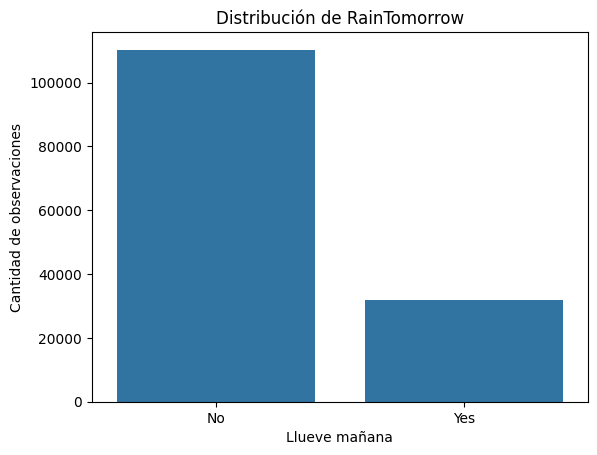

In [19]:
# Graficamos la distribución de la variable objetivo
sns.countplot(data=df, x="RainTomorrow")
plt.title("Distribución de RainTomorrow")
plt.xlabel("Llueve mañana")
plt.ylabel("Cantidad de observaciones")
plt.show()

La variable objetivo del problema es "RainTomorrow", que indica si al día siguiente llovió o no. En distribución observamos que la clase "No" aparece con mucha mayor frecuencia que la clase "Yes". Por ende el dataset está desbalanceado, por este motivo, además de accuracy, será necesario observar métricas como precision, recall y F1-score, especialmente para la clase "Yes". Sino el modelo puede no aprender a detectar bien los dias que si llueve


In [20]:
# eliminamos filas donde la variable objetivo no tiene valor
df = df.dropna(subset=["RainTomorrow"])

In [21]:
# verificamos
df["RainTomorrow"].value_counts(dropna=False)

RainTomorrow
No     110281
Yes     31872
Name: count, dtype: int64

Las filas con valores faltantes en "RainTomorrow" se eliminan porque esta columna es la variable objetivo. Si no se conoce si al día siguiente llovió o no, esa observación no puede utilizarse para entrenar ni evaluar un modelo supervisado.

In [22]:
# calculamos cantidad y porcentaje de valores faltantes por columna
faltantes = pd.DataFrame({
    "cantidad_faltantes": df.isna().sum(),
    "porcentaje_faltantes": df.isna().mean() * 100
})

faltantes = faltantes.sort_values(by="porcentaje_faltantes", ascending=False)

faltantes

,cantidad_faltantes,porcentaje_faltantes
Sunshine,67785,47.684537
Evaporation,60812,42.779259
Cloud3pm,57076,40.151105
Cloud9am,53641,37.734694
Pressure9am,14010,9.855578
Pressure3pm,13977,9.832364
WindDir9am,10009,7.041005
WindGustDir,9328,6.561944
WindGustSpeed,9268,6.519736
WindDir3pm,3776,2.656293


Observamos que algunas variables presentan un porcentaje alto de valores faltantes, por este motivo no se eliminan filas completas con valores faltantes, ya que eso implicaría perder una gran cantidad de observaciones. Se decide conservar inicialmente las variables y realizar la imputación más adelante después de separar los datos en entrenamiento y prueba.


In [23]:
# identificamos variables numéricas y categóricas
columnas_numericas = df.select_dtypes(include=["int64", "float64"]).columns
columnas_categoricas = df.select_dtypes(include=["object"]).columns

print("Variables numéricas:")
print(columnas_numericas)

print("\nVariables categóricas:")
print(columnas_categoricas)

Variables numéricas:
Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm'],
      dtype='str')

Variables categóricas:
Index(['Date', 'Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm',
       'RainToday', 'RainTomorrow'],
      dtype='str')


C:\Users\Usuario\AppData\Local\Temp\ipykernel_20600\160594843.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = df.select_dtypes(include=["object"]).columns


In [24]:
# obtenemos medidas descriptivas de las variables numéricas
df[columnas_numericas].describe().T

,count,mean,std,min,25%,50%,75%,max
MinTemp,141516.0,12.188866,6.422856,-9.7,7.6,12.0,16.8,34.1
MaxTemp,141831.0,23.228596,7.134436,-5.1,17.9,22.6,28.2,49.1
Rainfall,140747.0,2.350461,8.466267,0.0,0.0,0.0,0.8,371.0
Evaporation,81341.0,5.470149,4.188649,0.0,2.6,4.8,7.4,145.0
Sunshine,74368.0,7.624919,3.781656,0.0,4.9,8.5,10.6,14.5
WindGustSpeed,132885.0,39.985807,13.630314,6.0,31.0,38.0,48.0,135.0
WindSpeed9am,140805.0,14.025219,8.914326,0.0,7.0,13.0,19.0,130.0
WindSpeed3pm,139524.0,18.636901,8.858849,0.0,12.0,18.0,24.0,86.0
Humidity9am,140379.0,68.824619,19.085026,0.0,56.9,69.9,83.1,100.0
Humidity3pm,138544.0,51.475886,20.846540,0.0,36.5,51.9,65.6,100.0


Calculamos las medidas para las variables numéricas para detectar diferencias de escala entre variables

In [25]:
# obtenemos un resumen de las variables categóricas.
df[columnas_categoricas].describe().T

,count,unique,top,freq
Date,142153,3435,2013-03-02,49
Location,142153,49,Canberra,3417
WindGustDir,132825,16,W,9775
WindDir9am,132144,16,N,11389
WindDir3pm,138377,16,SE,10662
RainToday,140747,2,No,109296
RainTomorrow,142153,2,No,110281


En este caso interesa observar cuántas categorías distintas tiene cada variable y cuál es el valor más frecuente

### Histogramas

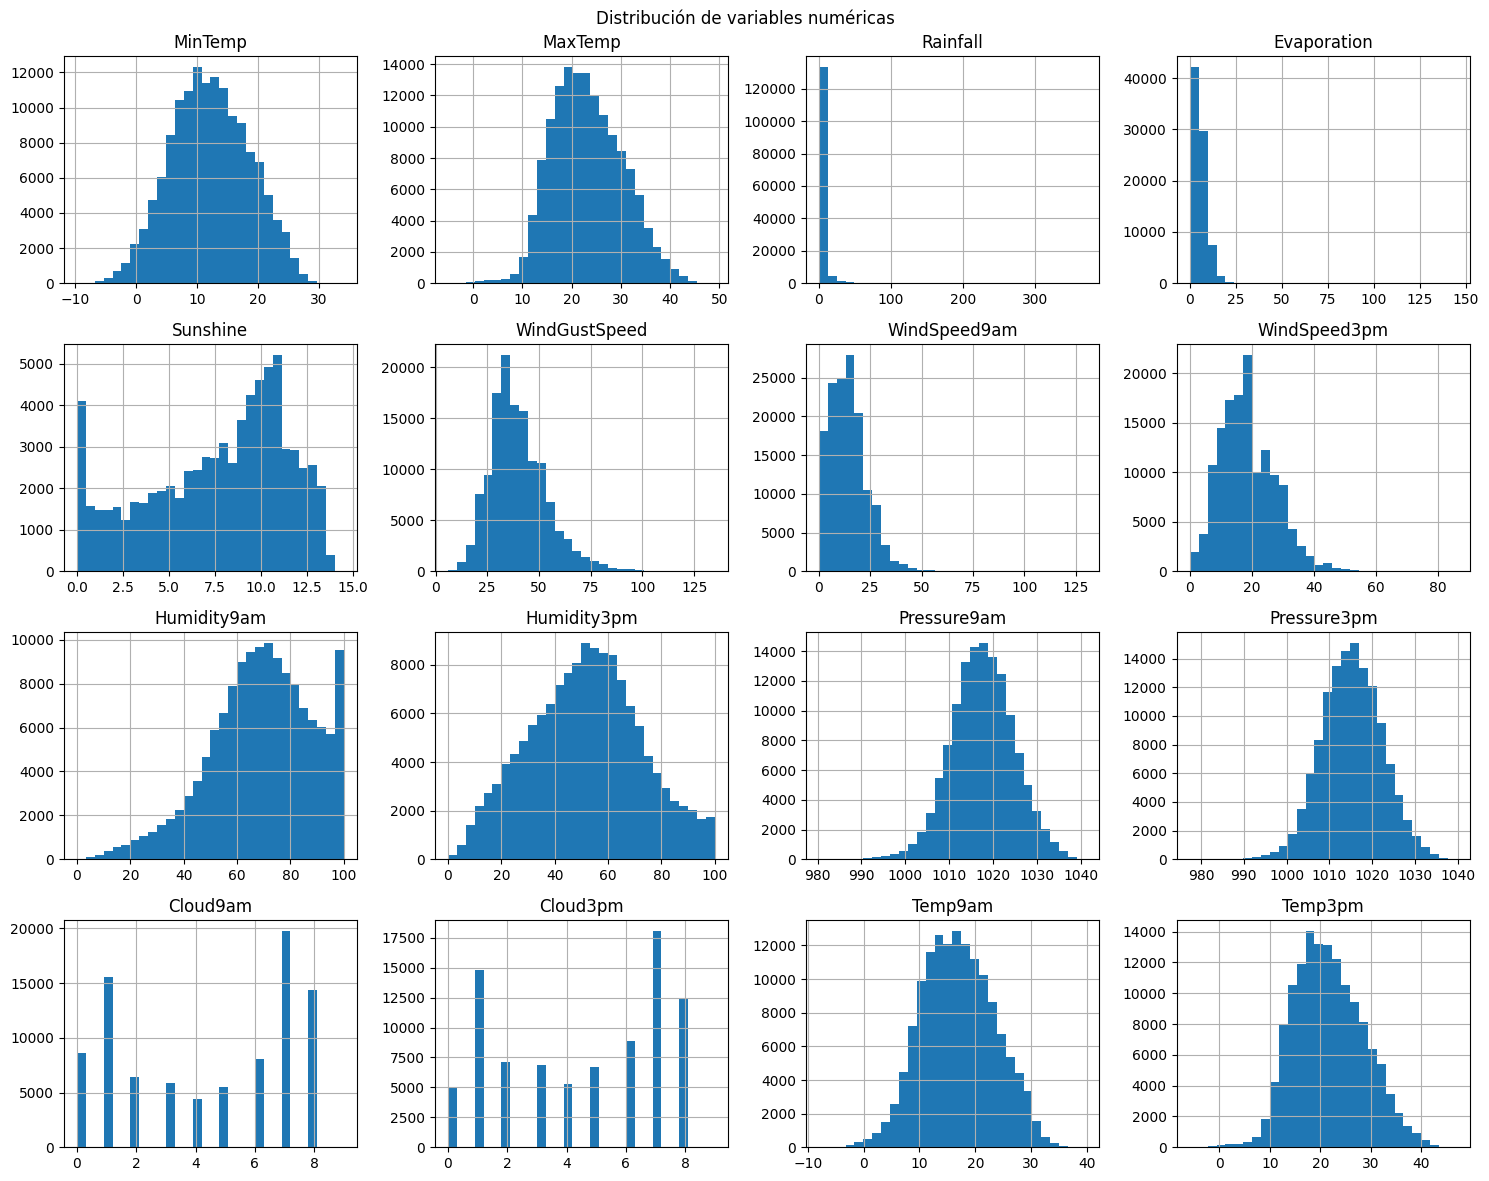

In [26]:
# graficamos histogramas para observar la distribución de las variables numéricas.
df[columnas_numericas].hist(figsize=(15, 12), bins=30)
plt.suptitle("Distribución de variables numéricas")
plt.tight_layout()
plt.show()

Graficamos histogramas de las variables numéricas para observar su distribución. Observamos que las variables no se encuentran en la misma escala, por ejemplo, temperatura, presión, humedad, velocidad del viento y lluvia tienen unidades y rangos distintos. Por este motivo, más adelante será necesario aplicar escalado

### Boxplots

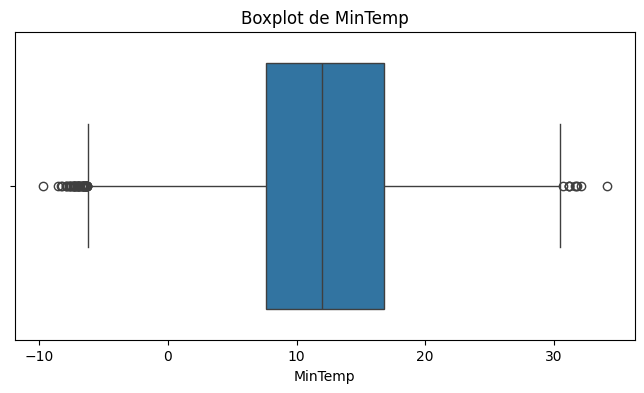

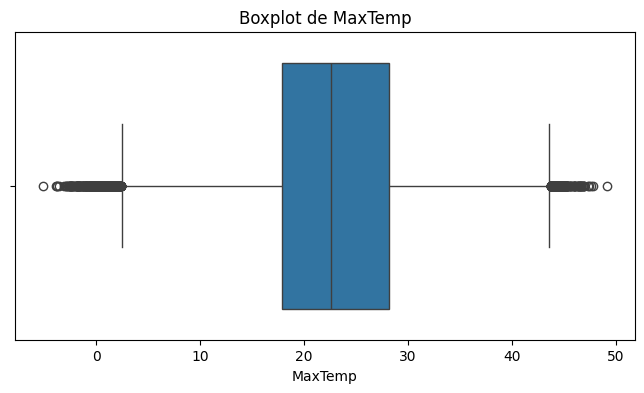

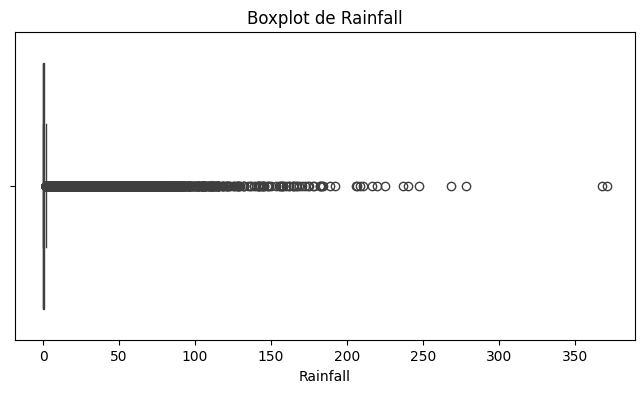

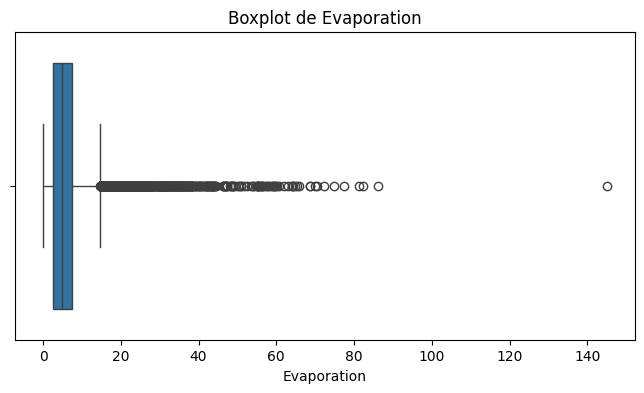

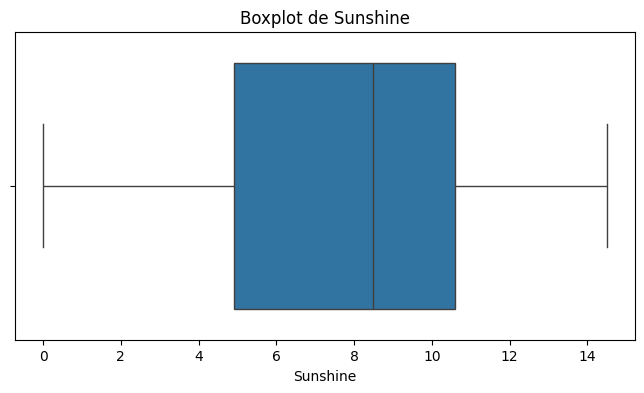

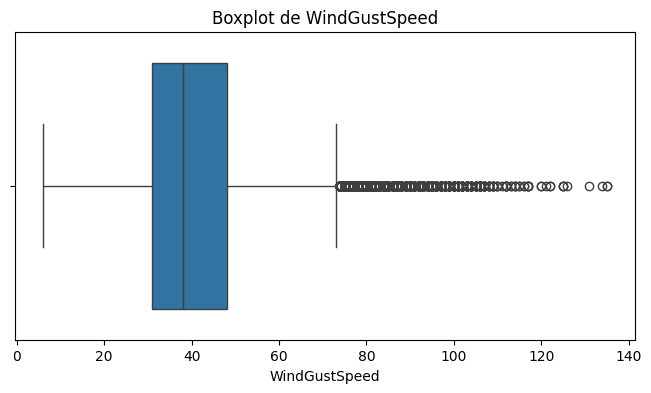

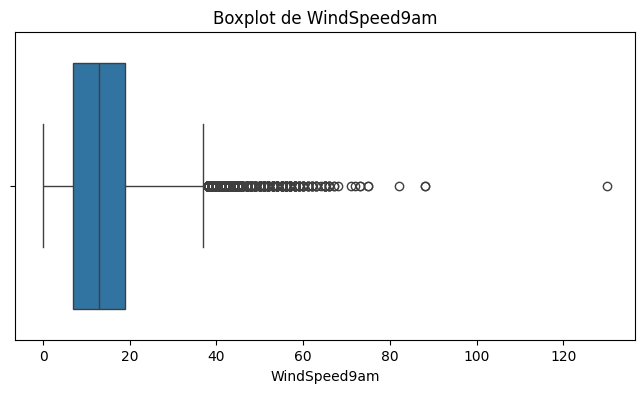

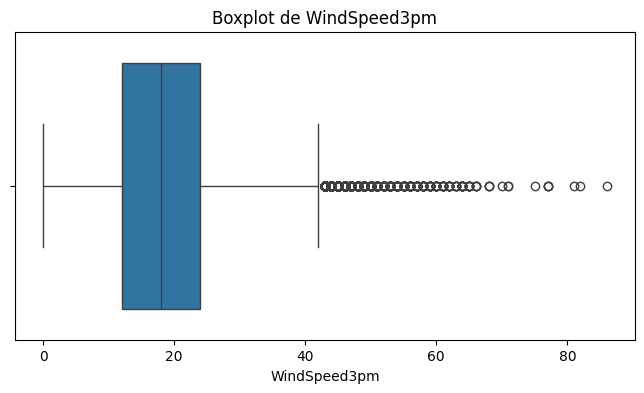

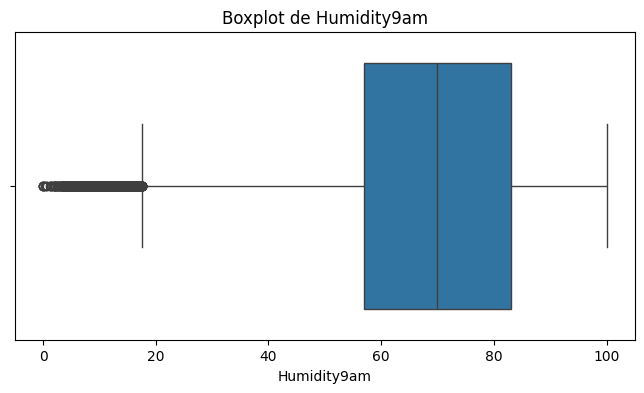

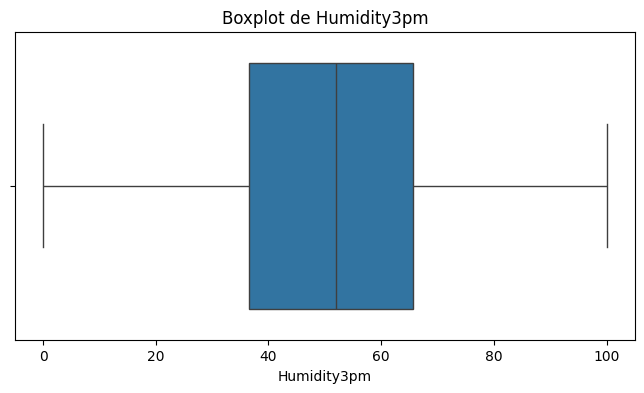

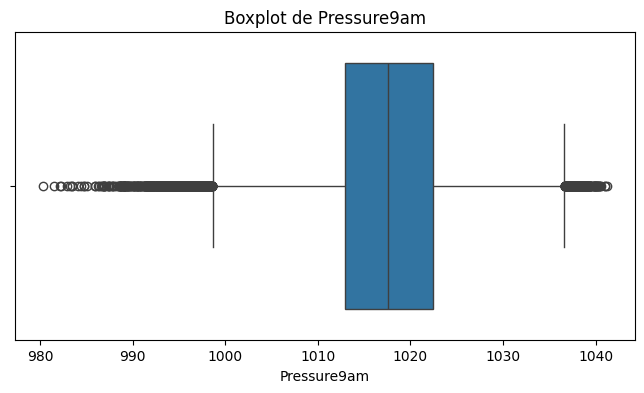

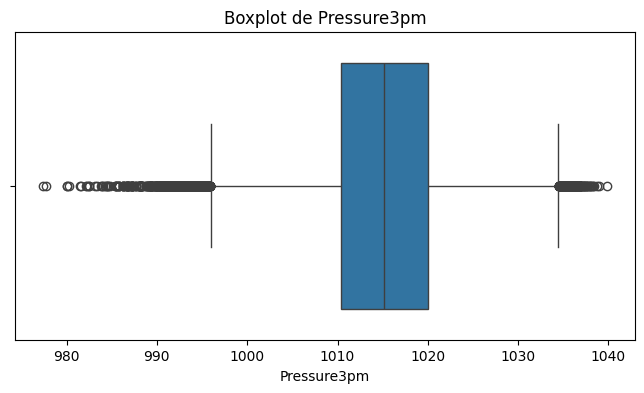

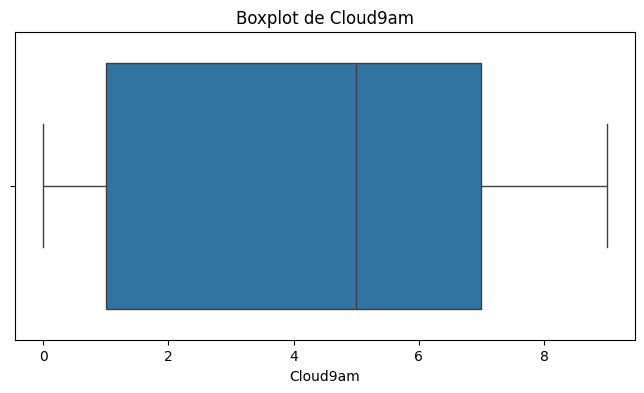

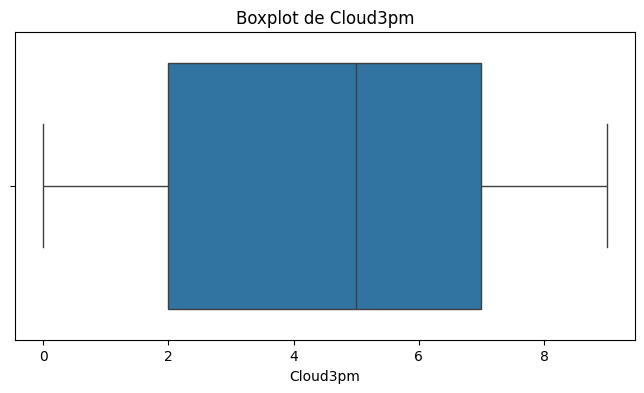

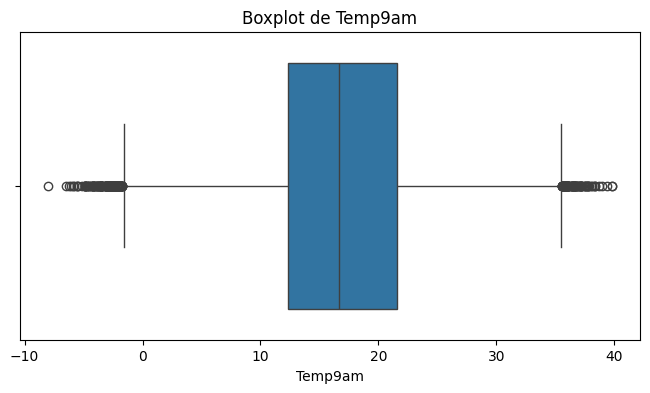

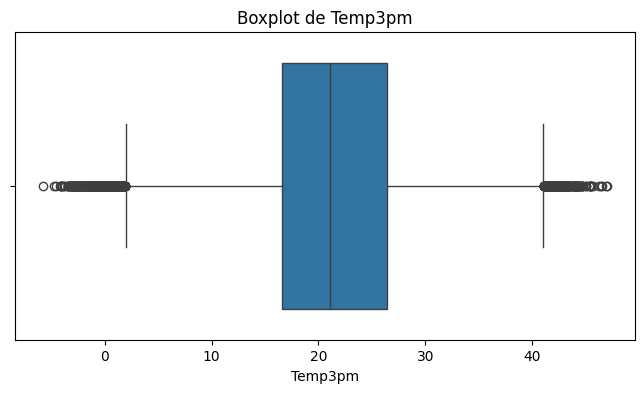

In [27]:
# Graficamos boxplots individuales para todas las variables numéricas.
for columna in columnas_numericas:
    plt.figure(figsize=(8, 4))
    sns.boxplot(data=df, x=columna)
    plt.title(f"Boxplot de {columna}")
    plt.xlabel(columna)
    plt.show()

In [28]:
# calculamos outliers por variable numérica usando el criterio del rango intercuartílico
resumen_outliers = []

for columna in columnas_numericas:
    q1 = df[columna].quantile(0.25)
    q3 = df[columna].quantile(0.75)
    iqr = q3 - q1

    limite_inferior = q1 - 1.5 * iqr
    limite_superior = q3 + 1.5 * iqr

    cantidad_outliers = ((df[columna] < limite_inferior) | (df[columna] > limite_superior)).sum()

    porcentaje_outliers = cantidad_outliers / df[columna].notna().sum() * 100

    resumen_outliers.append({
        "variable": columna,
        "limite_inferior": limite_inferior,
        "limite_superior": limite_superior,
        "cantidad_outliers": cantidad_outliers,
        "porcentaje_outliers": porcentaje_outliers
    })

resumen_outliers = pd.DataFrame(resumen_outliers)
resumen_outliers.sort_values(by="porcentaje_outliers", ascending=False)

,variable,limite_inferior,limite_superior,cantidad_outliers,porcentaje_outliers
2,Rainfall,-1.20,2.00,25224,17.921519
3,Evaporation,-4.60,14.60,1954,2.402233
5,WindGustSpeed,5.50,73.50,2899,2.181586
6,WindSpeed9am,-11.00,37.00,1891,1.342992
7,WindSpeed3pm,-6.00,42.00,1663,1.191910
8,Humidity9am,17.60,122.40,1425,1.015109
10,Pressure9am,998.65,1036.65,1181,0.921627
11,Pressure3pm,996.00,1034.40,915,0.713862
15,Temp3pm,1.90,41.10,752,0.539346
1,MaxTemp,2.45,43.65,485,0.341956


In [29]:
# verificamos si existen valores negativos en variables que no deberían ser negativas
variables_no_negativas = ["Rainfall", "Evaporation", "Sunshine","WindGustSpeed", "WindSpeed9am", "WindSpeed3pm","Humidity9am", "Humidity3pm","Pressure9am", "Pressure3pm", "Cloud9am", "Cloud3pm"]

valores_negativos = {}

for columna in variables_no_negativas:
    cantidad_negativos = (df[columna] < 0).sum()
    valores_negativos[columna] = cantidad_negativos

pd.Series(valores_negativos).sort_values(ascending=False)

Rainfall         0
Evaporation      0
Sunshine         0
WindGustSpeed    0
WindSpeed9am     0
WindSpeed3pm     0
Humidity9am      0
Humidity3pm      0
Pressure9am      0
Pressure3pm      0
Cloud9am         0
Cloud3pm         0
dtype: int64

In [30]:
# observamos los valores más frecuentes de Rainfall
df["Rainfall"].value_counts().head(20)

Rainfall
0.0    90244
0.2     8681
0.4     3749
0.6     2562
0.8     2028
1.0     1747
1.2     1515
1.4     1365
1.6     1187
1.8     1088
2.0     1024
2.2      973
2.4      835
2.6      831
2.8      723
3.0      706
3.2      662
3.4      602
3.8      589
4.0      554
Name: count, dtype: int64

Analizamos posibles valores extremos utilizando el criterio del rango intercuartílico (IQR). Este criterio marca como posibles outliers los valores menores a Q1 - 1.5 * IQR o mayores a Q3 + 1.5 * IQR. Observamos también que una gran parte de las observaciones tiene lluvia igual o cercana a 0 mm. Esto hace que el rango intercuartílico sea bajo y que valores de lluvia mayores a 2 mm sean marcados como outliers. Estos valores no necesariamente representan errores, sino que pueden ser días con mayor cantidad de lluvia.

### Matriz de correlación

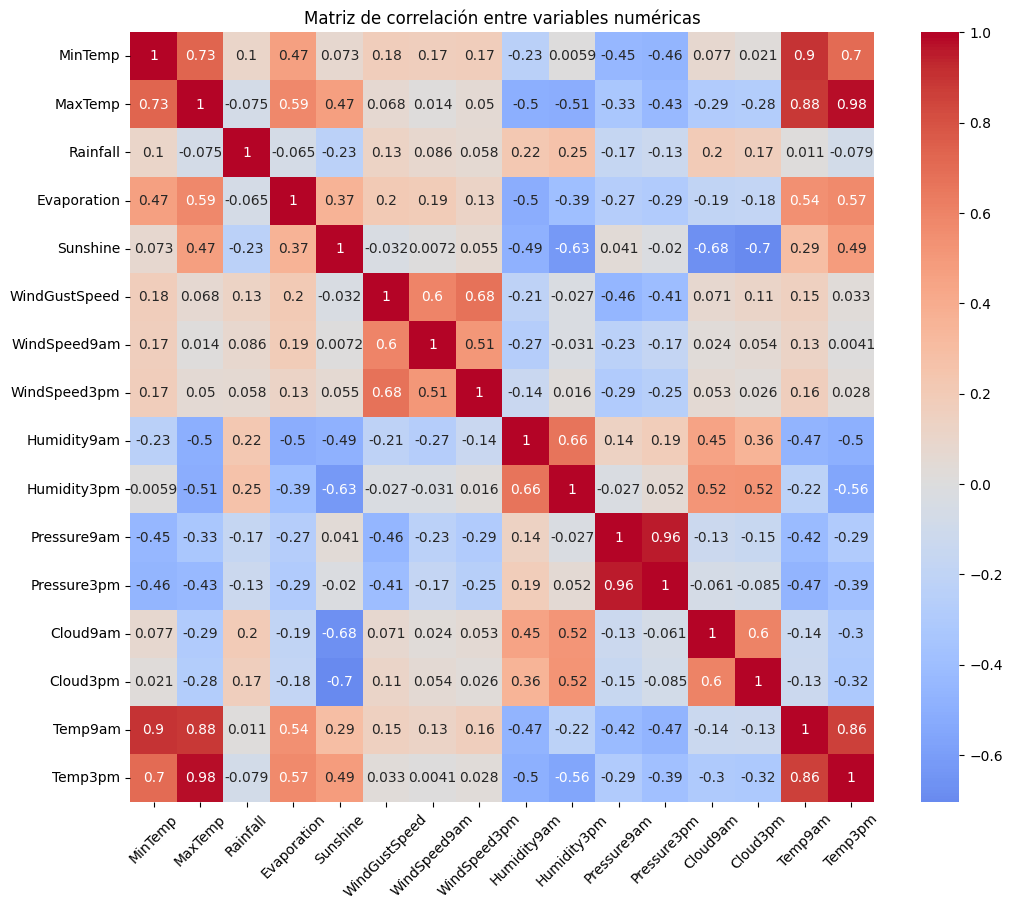

In [31]:
# calculamos la matriz de correlación entre variables numéricas
correlacion = df[columnas_numericas].corr()

plt.figure(figsize=(12, 10))
sns.heatmap(correlacion, cmap="coolwarm", center=0, annot=True)
plt.title("Matriz de correlación entre variables numéricas")
plt.xticks(rotation=45)
plt.show()

Se identifican correlaciones positivas fuertes entre variables relacionadas con la temperatura, como "MaxTemp" y "Temp3pm", y entre variables de presión, como "Pressure9am" y "Pressure3pm", también se observan correlaciones negativas entre "Sunshine" y variables como "Cloud9am", "Cloud3pm" y "Humidity3pm", lo cual es coherente con el clima, a mayor nubosidad o humedad o menor cantidad de horas de sol.
Esta matriz se utiliza como análisis exploratorio. No se eliminan variables automáticamente por correlación en esta etapa

In [32]:
# creamos una copia para preparar los datos que se usarán en los modelos
df_modelo = df.copy()

In [33]:
# convertimos Date a formato fecha y extraemos el mes como variable numérica
df_modelo["Date"] = pd.to_datetime(df_modelo["Date"])
df_modelo["Month"] = df_modelo["Date"].dt.month

# eliminamos la columna Date original para evitar codificar fechas completas
df_modelo = df_modelo.drop(columns=["Date"])

La columna "Date" se convierte a formato fecha y se utiliza para extraer el mes de la observación, lo que perermite conservar información  sobre estaciones, ya que la probabilidad de lluvia puede variar según la época del año. Luego se elimina la fecha completa, porque codificar cada día como una categoría distinta generaría muchas columnas y no aportaría una representación simple para el modelo.

In [34]:
# separamos variables predictoras y variable objetivo.
X = df_modelo.drop(columns=["RainTomorrow"])
y = df_modelo["RainTomorrow"]

In [35]:
# codificamos la variable objetivo: No = 0, Yes = 1.
y = y.map({"No": 0, "Yes": 1})

La variable objetivo se codifica como variable binaria donde "No" se representa con 0 y "Yes" con 1 para que la clase positiva corresponmda a los dias en los que si llueve

In [36]:
# ahora identificamos variables numéricas y categóricas dentro de X
columnas_numericas = X.select_dtypes(include=["int64", "float64"]).columns
columnas_categoricas = X.select_dtypes(include=["object"]).columns

print("Variables numéricas:")
print(columnas_numericas)

print("\nVariables categóricas:")
print(columnas_categoricas)

Variables numéricas:
Index(['MinTemp', 'MaxTemp', 'Rainfall', 'Evaporation', 'Sunshine',
       'WindGustSpeed', 'WindSpeed9am', 'WindSpeed3pm', 'Humidity9am',
       'Humidity3pm', 'Pressure9am', 'Pressure3pm', 'Cloud9am', 'Cloud3pm',
       'Temp9am', 'Temp3pm'],
      dtype='str')

Variables categóricas:
Index(['Location', 'WindGustDir', 'WindDir9am', 'WindDir3pm', 'RainToday'], dtype='str')


C:\Users\Usuario\AppData\Local\Temp\ipykernel_20600\3411176390.py:3: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  columnas_categoricas = X.select_dtypes(include=["object"]).columns


Se vuelven a identificar las columnas numéricas y categóricas únicamente dentro de "X" para no incluir la variable objetivo dentro de las predictoras

In [37]:
# dividimos los datos en entrenamiento y prueba manteniendo la proporción de clases
X_train, X_test, y_train, y_test = train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

Se divide el dataset en conjuntos de entrenamiento y prueba. Usamos un 20% de los datos para prueba y se mantiene la proporción de clases mediante "stratify=y", ya que la variable objetivo está desbalanceada

In [38]:
# definimos el preprocesamiento para variables numéricas
preprocesamiento_numerico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),
    ("scaler", StandardScaler())
])

# definimos el preprocesamiento para variables categóricas
preprocesamiento_categorico = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore"))
])

# combinamos ambos preprocesamientos
preprocesamiento = ColumnTransformer(transformers=[
    ("num", preprocesamiento_numerico, columnas_numericas),
    ("cat", preprocesamiento_categorico, columnas_categoricas)
])

Separamos el preprocesamiento según tipo de variable. Para las numéricas usamos imputación con mediana y escalado estándar. Para las categóricas usamos imputación con la categoría más frecuente y codificación one-hot. Todo esto se coloca dentro de un Pipeline y un ColumnTransformer para que se ajuste solo con el conjunto de entrenamiento y así evitar fuga de datos.

## Ítem 2: Regresión logística

In [39]:
# creamos un Pipeline que combina el preprocesamiento y la regresión logística
modelo_logistico = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("clasificador", LogisticRegression(max_iter=1000, random_state=42))
])

In [40]:
# entrenamos el modelo utilizando el conjunto de entrenamiento
modelo_logistico.fit(X_train, y_train)

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('preprocesamiento', ...), ('clasificador', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"transformers transformers: list of tuplesList of (name, transformer, columns) tuples specifying thetransformer objects to be applied to subsets of the data.name : str Like in Pipeline and FeatureUnion, this allows the transformer and its parameters to be set using ``set_params`` and searched in grid search.transformer : {'drop', 'passthrough'} or estimator Estimator must support :term:`fit` and :term:`transform`. Special-cased strings 'drop' and 'passthrough' are accepted as well, to indicate to drop the columns or to pass them through untransformed, respectively.columns : str, array-like of str, int, array-like of int, array-like of bool, slice or callable Indexes the data on its second axis. Integers are interpreted as positional columns, while strings can reference DataFrame columns by name. A scalar string or int should be used where ``transformer`` expects X to be a 1d array-like (vector), otherwise a 2d array will be passed to the transformer. A callable is passed the input data `X` and can return any of the above. To select multiple columns by name or dtype, you can use :obj:`make_column_selector`.","[('num', ...), ('cat', ...)]"
,"remainder remainder: {'drop', 'passthrough'} or estimator, default='drop'By default, only the specified columns in `transformers` aretransformed and combined in the output, and the non-specifiedcolumns are dropped. (default of ``'drop'``).By specifying ``remainder='passthrough'``, all remaining columns thatwere not specified in `transformers`, but present in the data passedto `fit` will be automatically passed through. This subset of columnsis concatenated with the output of the transformers. For dataframes,extra columns not seen during `fit` will be excluded from the outputof `transform`.By setting ``remainder`` to be an estimator, the remainingnon-specified columns will use the ``remainder`` estimator. Theestimator must support :term:`fit` and :term:`transform`.Note that using this feature requires that the DataFrame columnsinput at :term:`fit` and :term:`transform` have identical order.",'drop'
,"sparse_threshold sparse_threshold: float, default=0.3If the output of the different tran

In [41]:
# obtenemos las predicciones de clase sobre el conjunto de prueba
y_pred_logistico = modelo_logistico.predict(X_test)

In [42]:
# obtenemos las probabilidades de pertenecer a la clase positiva
y_proba_logistico = modelo_logistico.predict_proba(X_test)[:, 1]

In [43]:
# observamos las primeras predicciones de clase
y_pred_logistico[:10]

array([0, 0, 0, 0, 0, 1, 0, 0, 1, 1])

In [44]:
# observamos las primeras probabilidades estimadas de lluvia
y_proba_logistico[:10]

array([0.04251907, 0.04679498, 0.02735395, 0.05624436, 0.1645839 ,
       0.7185793 , 0.13481261, 0.10273473, 0.68442349, 0.98409344])

In [45]:
# calculamos métricas principales para evaluar el modelo de regresión logística
accuracy_logistico = accuracy_score(y_test, y_pred_logistico)
precision_logistico = precision_score(y_test, y_pred_logistico)
recall_logistico = recall_score(y_test, y_pred_logistico)
f1_logistico = f1_score(y_test, y_pred_logistico)
auc_logistico = roc_auc_score(y_test, y_proba_logistico)

print("Accuracy:", accuracy_logistico)
print("Precision:", precision_logistico)
print("Recall:", recall_logistico)
print("F1-score:", f1_logistico)
print("ROC-AUC:", auc_logistico)

Accuracy: 0.8477014526397243
Precision: 0.7304916553901669
Recall: 0.5081581424537183
F1-score: 0.5993708364174686
ROC-AUC: 0.8700858007462453


Se calculan distintas métricas porque el dataset está desbalanceado. En este caso, accuracy por si sola puede ser insuficiente, ya que un modelo podría acertar muchos casos de la clase mayoritaria (No) y aun así detectar mal los casos de lluvia (Yes). Por este motivo se analizan también precision, recall, F1-score y ROC-AUC. La clase positiva corresponde a "RainTomorrow = Yes", es decir, los días en los que sí llueve al día siguiente.

Con el umbral por defecto de 0.5, si la probabilidad es mayor o igual a 0.5 el modelo predice lluvia, si es menor, predice que no llueve. Con este umbral el modelo obtuvo una accuracy de 0.847, pero el recall fue de 0.508. Esto significa que aunque acierta muchos casos en general, detecta aproximadamente la mitad de los días en los que realmente llueve. El ROC-AUC fue de 0.870 lo cual indica que las probabilidades del modelo separan bastante bien los casos de lluvia y no lluvia, por eso el problema no necesariamente está en que el modelo no sirva, sino en que el umbral 0.5 puede no ser el más conveniente si queremos detectar más días de lluvia. Bajar el umbral podría aumentar el recall para detectar más lluvias reales pero la desventaja es que también podrían aumentar los falsos positivos

## Ítem 3: implementación del modelo base

In [48]:
# implementamos modelo base con "DummyClassifier"
modelo_base = Pipeline(steps=[
    ("preprocesamiento", preprocesamiento),
    ("clasificador", DummyClassifier(strategy="most_frequent", random_state=42))
    ])

modelo_base.fit(X_train, y_train)
y_pred_base = modelo_base.predict(X_test)

print("Resultados: \n")
print(classification_report(y_test, y_pred_base))
print(confusion_matrix(y_test, y_pred_base))

Resultados: 

              precision    recall  f1-score   support

           0       0.78      1.00      0.87     22057
           1       0.00      0.00      0.00      6374

    accuracy                           0.78     28431
   macro avg       0.39      0.50      0.44     28431
weighted avg       0.60      0.78      0.68     28431

[[22057     0]
 [ 6374     0]]


c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\Usuario\AppData\Local\Programs\Python\Python311\Lib\site-packages\sklearn\metrics\_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_p

El modelo base predice siempre la clase mayoritaria "no llueve", con un accuracy del 78% pero recall 0 para la clase positiva, por lo que siempre obtendremos como predicción "no llueve", sin importar si alguno de los datos ingresados muestra claras condiciones de lluvia